<a href="https://colab.research.google.com/github/tegga8/GEN_AI_Fundamentals/blob/main/BETA_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [4]:
latent_dim = 10
beta_values = [0.5, 1, 2, 4, 10]
epochs = 5
batch_size = 128


In [6]:
# Sampling Layer

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(
            shape = tf.shape(z_mean)
        )
        return (
            z_mean + tf.exp(0.5 * z_log_var) * epsilon
        )

In [9]:
# Encoder

def create_encoder():
    encoder_input = layers.Input(shape = (784,))
    x = layers.Dense(256, activation = 'relu')(encoder_input)
    z_mean = layers.Dense(latent_dim, name = 'z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name = 'z_log_var')(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = Model(encoder_input, [z_mean, z_log_var, z], name = 'Encoder')
    return encoder

In [11]:
# Decoder

def create_decoder():
  latent_inputs = layers.Input(
      shape = (latent_dim,)
  )
  x = layers.Dense(
      256, activation = 'relu'
  )(latent_inputs)
  decoder_output = layers.Dense(
      784, activation = 'sigmoid'
  )(x)
  decoder = Model(latent_inputs, decoder_output, name = 'Decoder')
  return decoder

In [13]:
from os import name
# Beta VAE class

class BetaVAE(Model):
  def __init__(self, encoder, decoder, beta):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder
    self.beta = beta
    self.total_loss_tracker = tf.keras.metrics.Mean(name = 'loss')
    self.recon_loss_tracker = tf.keras.metrics.Mean(name = 'reconstruction_loss')
    self.kl_loss_tracker = tf.keras.metrics.Mean(name = 'kl_loss')

  @property
  def metrics(self):
    return [self.total_loss_tracker,
            self.recon_loss_tracker,
            self.kl_loss_tracker
           ]

  def train_step(self, data):
    with tf.GradientTape() as tape:
      z_mean, z_log_var, z = self.encoder(data)
      reconstruction = self.decoder(z)
      reconstruction_loss = tf.reduce_mean(
          tf.reduce_sum(
              tf.keras.losses.binary_crossentropy(data, reconstruction),
              axis = -1
          )
      )

      kl_loss = -0.5 * tf.reduce_mean(
          tf.reduce_sum(
              1 + z_log_var
              - tf.square(z_mean)
               - tf.exp(z_log_var),
              axis = 1
              )
      )

      total_loss = (
          reconstruction_loss + self.beta * kl_loss
      )

      grads = tape.gradient(total_loss, self.trainable_weights)
      self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
      self.total_loss_tracker.update_state(total_loss)
      self.recon_loss_tracker.update_state(reconstruction_loss)
      self.kl_loss_tracker.update_state(kl_loss)
      return {
          'loss': self.total_loss_tracker.result(),
          'reconstruction_loss': self.recon_loss_tracker.result(),
          'kl_loss': self.kl_loss_tracker.result()
      }


In [14]:
# Training with diff Beta values
recon_losses = []
kl_losses = []
trained_models = {}
for beta in beta_values:
  print(f"\nTraining Beta: {beta}")
  encoder = create_encoder()
  decoder = create_decoder()
  model = BetaVAE(encoder, decoder, beta)
  model.compile(optimizer = tf.keras.optimizers.Adam())
  history = model.fit(
      x_train,
      epochs = epochs,
      batch_size = batch_size,
      verbose = 1
  )
  trained_models[beta] = model
  recon_losses.append(history.history['reconstruction_loss'][-1])
  kl_losses.append(history.history['kl_loss'][-1])


Training Beta: 0.5
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - kl_loss: 6.9100 - loss: 32.3670 - reconstruction_loss: 28.9120
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - kl_loss: 8.5335 - loss: 25.6536 - reconstruction_loss: 21.3868
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - kl_loss: 9.3876 - loss: 24.6480 - reconstruction_loss: 19.9542
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 9.7778 - loss: 24.1787 - reconstruction_loss: 19.2898
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - kl_loss: 9.9915 - loss: 23.8857 - reconstruction_loss: 18.8899

Training Beta: 1
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - kl_loss: 3.0507 - loss: 35.0472 - reconstruction_loss: 31.9964
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 4.3514 - loss: 29.2084 - reconstruction_loss: 24.8570
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - kl_loss: 4.9255 - loss: 28.4544 - reconstruction_loss: 23.5288
Epoch 4/5
469/469 ━━━━

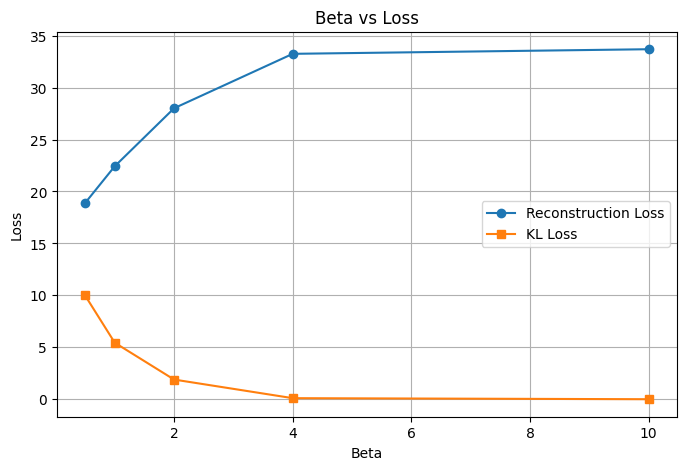

In [15]:
plt.figure(figsize = (8, 5))
plt.plot(beta_values, recon_losses, marker='o', label = 'Reconstruction Loss')
plt.plot(beta_values, kl_losses, marker='s', label = 'KL Loss')
plt.xlabel('Beta')
plt.ylabel('Loss')
plt.title('Beta vs Loss')
plt.legend()
plt.grid(True)
plt.show()

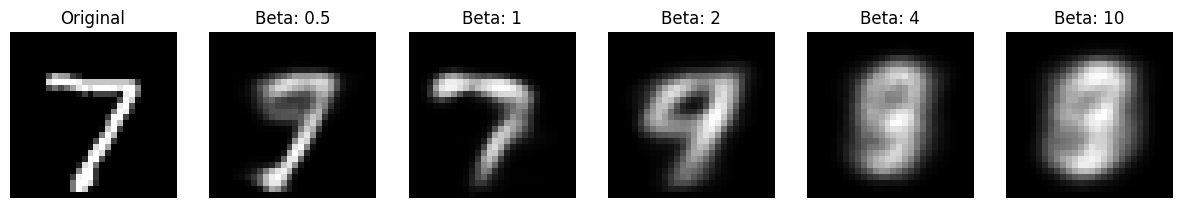

In [16]:
# Recontruction

sample = x_test[0:1]
fig, axes = plt.subplots(1, len(beta_values)+1, figsize = (15, 3))
axes[0].imshow(
    sample.reshape(28, 28),
    cmap = 'gray'
)
axes[0].set_title(
    "Original"
)
axes[0].axis('off')
for i, beta in enumerate(beta_values):
  model = trained_models[beta]
  z_mean, z_log_var, z = model.encoder.predict(sample, verbose=0)
  reconstructed = model.decoder.predict(z, verbose=0)
  axes[i+1].imshow(
      reconstructed.reshape(28, 28),
      cmap = 'gray'
  )
  axes[i+1].set_title(
      f"Beta: {beta}"
  )
  axes[i+1].axis('off')
plt.show ()
